<a href="https://colab.research.google.com/github/samihannn/aml-exps-samihan/blob/main/AML_Exp_5%266.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully.

--- Correlation Heatmap ---


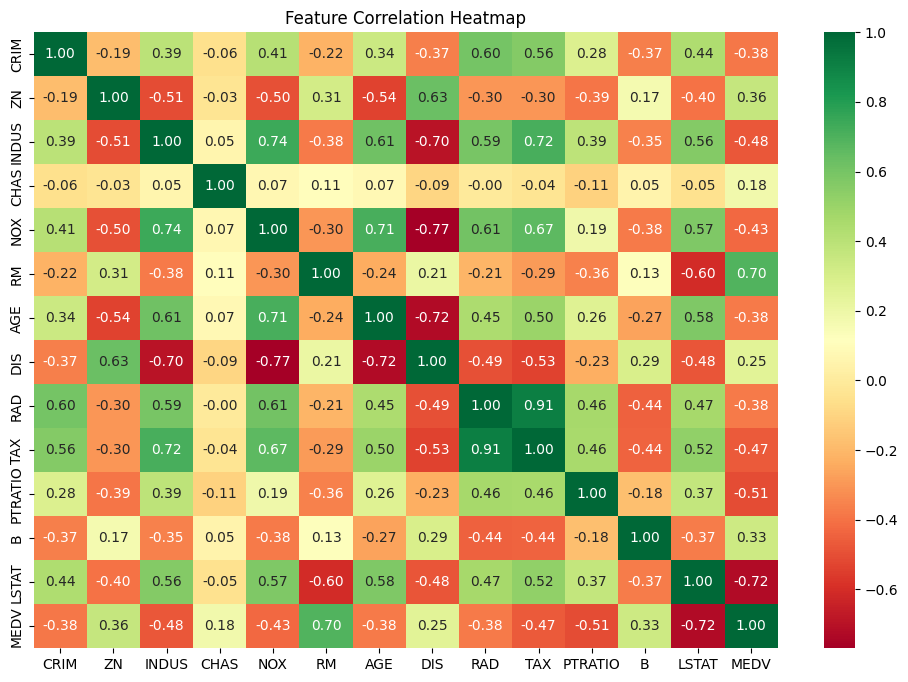


--- Model Evaluation ---
Linear Regression    | R2 Score: 0.6591
Decision Tree        | R2 Score: 0.6810
Random Forest        | R2 Score: 0.8875
Gradient Boosting    | R2 Score: 0.9002

Final Results:


,Model,MAE,MSE,R2 Score
3,Gradient Boosting,1.922403,7.320872,0.900171
2,Random Forest,2.066794,8.250247,0.887497
1,Decision Tree,2.895098,23.393039,0.681006
0,Linear Regression,3.148737,24.999385,0.659101


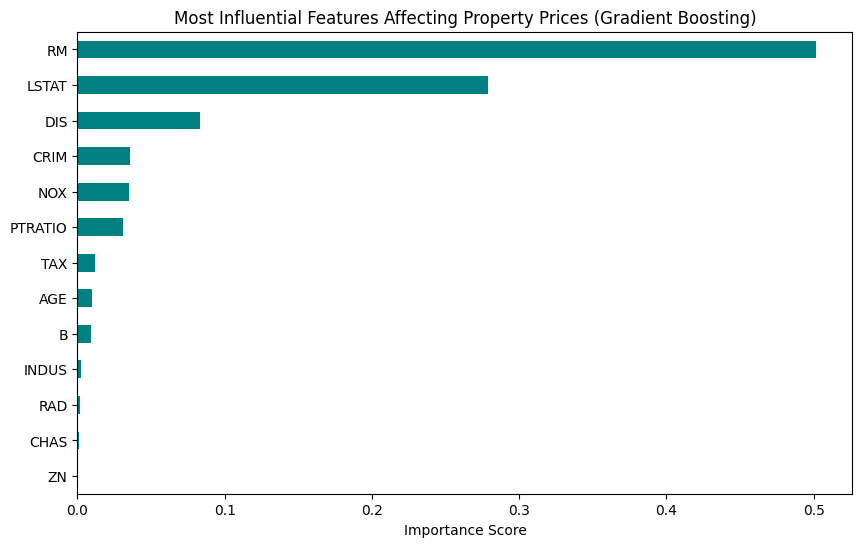

/tmp/ipython-input-1306/3312981528.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="R2 Score", y="Model", data=results_df, palette="viridis")
/tmp/ipython-input-1306/3312981528.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="MAE", y="Model", data=results_df, palette="magma")


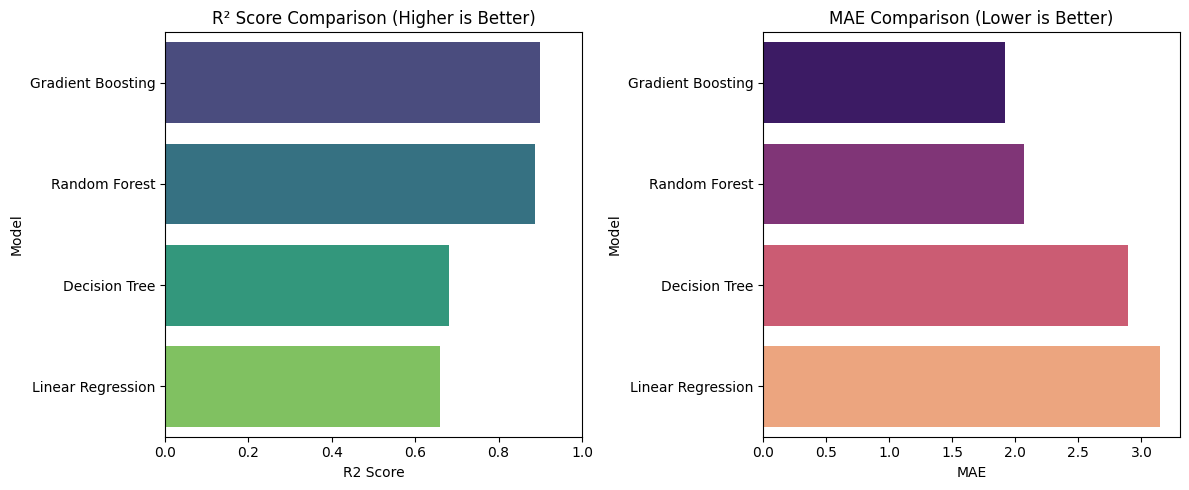

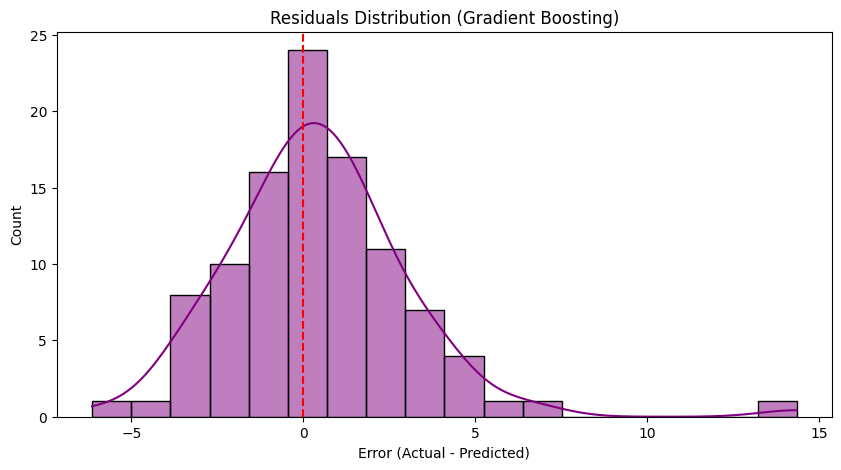


SAMPLE PREDICTION (Using Gradient Boosting)
Actual Price:    23.60
Predicted Price: 23.23
Difference:      0.37

CONCLUSION:
The best model for Pune Housing is the Gradient Boosting.
It captures 90.02% of the price variation.
On average, its predictions are off by only 1.92 units.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    df = pd.read_csv('HousingData.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: HousingData.csv not found. Please upload the file to your Colab session.")

df = df.fillna(df.median())

print("\n--- Correlation Heatmap ---")
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

target = 'MEDV'
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
trained_models = {}

print("\n--- Model Evaluation ---")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE": mae, "MSE": mse, "R2 Score": r2})
    trained_models[name] = model
    print(f"{name:20} | R2 Score: {r2:.4f}")

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print("\nFinal Results:")
display(results_df)

best_model_name = "Gradient Boosting"
importances = trained_models[best_model_name].feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='teal')
plt.title(f"Most Influential Features Affecting Property Prices ({best_model_name})")
plt.xlabel("Importance Score")
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x="R2 Score", y="Model", data=results_df, palette="viridis")
plt.title("R² Score Comparison (Higher is Better)")
plt.xlim(0, 1)

plt.subplot(1, 2, 2)
sns.barplot(x="MAE", y="Model", data=results_df, palette="magma")
plt.title("MAE Comparison (Lower is Better)")

plt.tight_layout()
plt.show()

best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)
residuals = y_test - y_pred_best

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color="purple")
plt.axvline(x=0, color='red', linestyle='--')
plt.title(f"Residuals Distribution ({best_model_name})")
plt.xlabel("Error (Actual - Predicted)")
plt.show()

def predict_house_price(input_data):
    """
    Function to take raw input, scale it, and predict price.
    Input should be a list/array in the order of:
    [CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT]
    """
    sample_df = pd.DataFrame([input_data], columns=X.columns)

    sample_scaled = scaler.transform(sample_df)

    prediction = best_model.predict(sample_scaled)
    return prediction[0]

sample_house = X_test.iloc[0].values
actual_price = y_test.iloc[0]
predicted_price = predict_house_price(sample_house)

print("\n" + "="*40)
print(f"SAMPLE PREDICTION (Using {best_model_name})")
print("="*40)
print(f"Actual Price:    {actual_price:.2f}")
print(f"Predicted Price: {predicted_price:.2f}")
print(f"Difference:      {abs(actual_price - predicted_price):.2f}")
print("="*40)

best_row = results_df.iloc[0]
print(f"\nCONCLUSION:")
print(f"The best model for Pune Housing is the {best_row['Model']}.")
print(f"It captures {best_row['R2 Score']*100:.2f}% of the price variation.")
print(f"On average, its predictions are off by only {best_row['MAE']:.2f} units.")